In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
WORK_DIR = '/content/drive/MyDrive/玉水写真'

import os
os.chdir(WORK_DIR)
os.getcwd()

'/content/drive/MyDrive/玉水写真'

In [3]:
os.listdir()

['果実1.jpg',
 '果実2.jpg',
 '適熟E.jpg',
 '果実B.jpg',
 '果実C.jpg',
 '果実A.jpg',
 '果点拡大版A.jpg',
 '未熟D.jpg',
 '果実B拡大版.jpg',
 '果実C拡大版.jpg',
 '未熟D拡大版.jpg',
 '適熟E拡大版.jpg',
 '果実1拡大.jpg',
 '果実2拡大.jpg']

In [4]:
import cv2

# Load an image (assuming '果点拡大版A.jpg' is in the current directory)
image_path = '果点拡大版A.jpg'
image = cv2.imread(image_path)

# Check if the image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert the image to Lab color space
    lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    # Print the shape of the Lab image
    print(f"Lab Image dimensions: {lab_image.shape}")

Lab Image dimensions: (206, 151, 3)


In [5]:
l_channel = lab_image[:, :, 0]

print(f"L-channel dimensions: {l_channel.shape}")

L-channel dimensions: (206, 151)


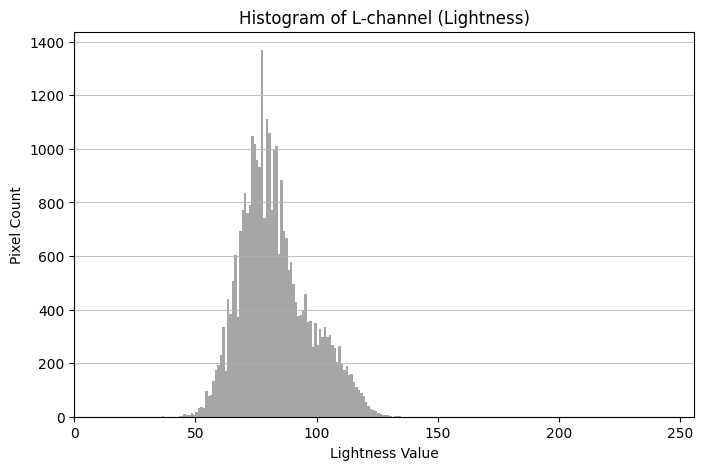

In [6]:
import matplotlib.pyplot as plt

# Compute and plot the histogram of the L-channel
plt.figure(figsize=(8, 5))
plt.hist(l_channel.flatten(), bins=256, range=[0, 256], color='gray', alpha=0.7)
plt.title('Histogram of L-channel (Lightness)')
plt.xlabel('Lightness Value')
plt.ylabel('Pixel Count')
plt.xlim([0, 256])
plt.grid(axis='y', alpha=0.75)
plt.show()

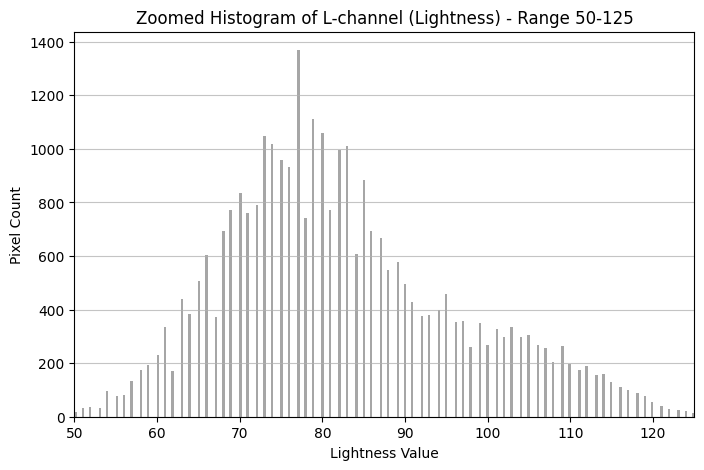

In [7]:
import matplotlib.pyplot as plt

# Regenerate and plot the histogram of the L-channel, zoomed to 50-125
plt.figure(figsize=(8, 5))
plt.hist(l_channel.flatten(), bins=256, range=[50, 125], color='gray', alpha=0.7)
plt.title('Zoomed Histogram of L-channel (Lightness) - Range 50-125')
plt.xlabel('Lightness Value')
plt.ylabel('Pixel Count')
plt.xlim([50, 125])
plt.grid(axis='y', alpha=0.75)
plt.show()

In [8]:
import cv2

# Apply Otsu's binarization to the L-channel
# The first return value is the optimal threshold, which we don't need to store here.
_, binary_l_channel = cv2.threshold(l_channel, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

print(f"Shape of binarized L-channel: {binary_l_channel.shape}")

Shape of binarized L-channel: (206, 151)


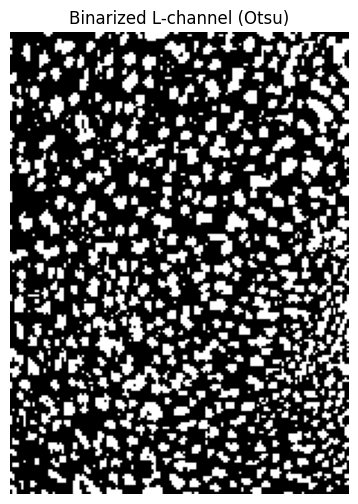

In [9]:
import matplotlib.pyplot as plt

# Display the binarized L-channel image
plt.figure(figsize=(6, 6))
plt.imshow(binary_l_channel, cmap='gray')
plt.title('Binarized L-channel (Otsu)')
plt.axis('off')
plt.show()

In [10]:
!pip install japanize_matplotlib
import japanize_matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 39.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=d4d1c144a45283fa35e8054f4beed94a462a0c17bcd57f2ffe2838d0a8c054f5
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib


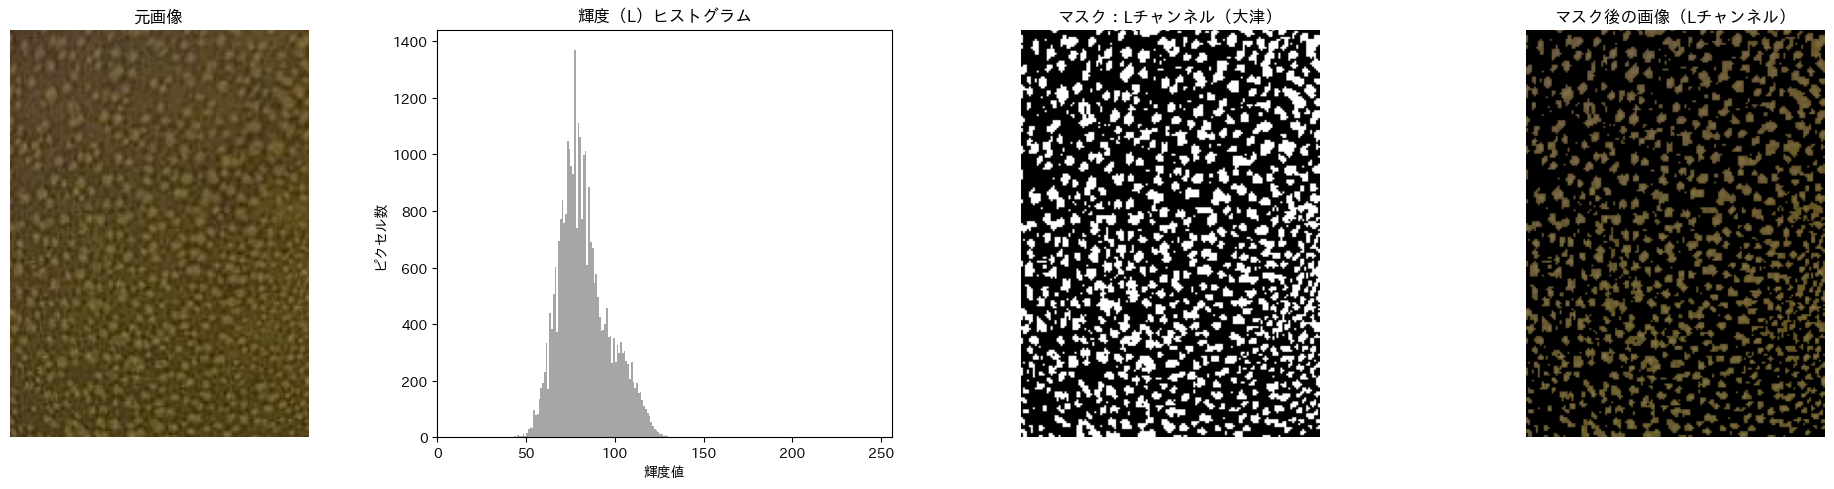

In [11]:
import matplotlib.pyplot as plt
import cv2

# Convert the BGR image to RGB for display
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Re-calculate the optimal threshold for the L-channel (if not already stored)
# binary_l_channel is already available from cell tZ5dVtlkw8Ew
_, th_l_channel = cv2.threshold(l_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Apply the binary_l_channel as a mask to the original image
masked_image_l_channel = cv2.bitwise_and(img_rgb, img_rgb, mask=binary_l_channel)

# Create a figure with four subplots
fig = plt.figure(figsize=(20,5))

# Subplot 1: Original Image
plt.subplot(1,4,1)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('元画像')

# Subplot 2: Histogram of L-channel
plt.subplot(1,4,2)
plt.hist(l_channel.flatten(), bins=256, range=[0, 256], color='gray', alpha=0.7)
plt.title('輝度（L）ヒストグラム')
plt.xlabel('輝度値')
plt.ylabel('ピクセル数')
plt.xlim([0, 256])

# Subplot 3: Binarized L-channel (Otsu)
plt.subplot(1,4,3)
plt.imshow(binary_l_channel, cmap='gray')
plt.axis('off')
plt.title('マスク：Lチャンネル（大津）')

# Subplot 4: Masked Image
plt.subplot(1,4,4)
plt.imshow(masked_image_l_channel)
plt.axis('off')
plt.title('マスク後の画像（Lチャンネル）')

plt.tight_layout()
plt.show()

In [12]:
import cv2

# Convert the original image to RGB for matplotlib display
img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [13]:
# Invert the binary L-channel mask
inverted_binary_l_channel = cv2.bitwise_not(binary_l_channel)

In [14]:
# Apply the inverted mask to the original RGB image
masked_image_inverted = cv2.bitwise_and(img_rgb, img_rgb, mask=inverted_binary_l_channel)

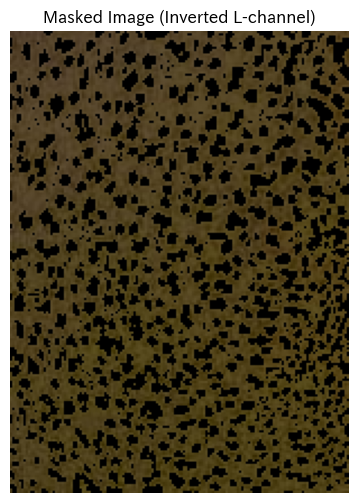

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(masked_image_inverted)
plt.title('Masked Image (Inverted L-channel)')
plt.axis('off')
plt.show()

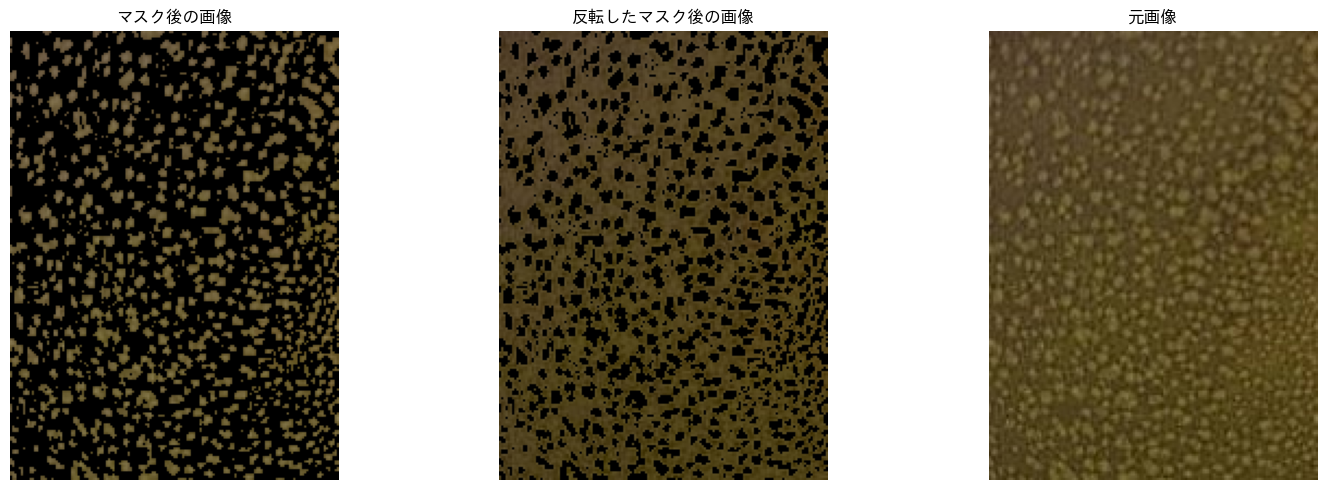

In [19]:
# Create a figure with four subplots
fig = plt.figure(figsize=(20,5))

# Subplot 1:Masked Image
plt.subplot(1,4,1)
plt.imshow(masked_image_l_channel)
plt.axis('off')
plt.title('マスク後の画像')


# Subplot 2: Masked Image (Inverted L-channel)
plt.subplot(1,4,2)
plt.imshow(masked_image_inverted)
plt.title('反転したマスク後の画像')
plt.axis('off')


# Subplot 3: Original Image
plt.subplot(1,4,3)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('元画像')


plt.tight_layout()
plt.show()